In [17]:
import pandas as pd

# Input files
PROBE_ROWS_PATH = "/content/probe_results_rows.csv"
TOPUP_ROWS_PATH = "/content/probe_results_topup_rows.csv"

# Output file
OUT_PATH = "/content/probe_results_combined.csv"

TIME_COL_CANDIDATES = ["start_time_utc", "timestamp", "time", "created_at", "start_time", "ts"]


def pick_existing_col(df, candidates):
    cols = set(df.columns)
    for c in candidates:
        if c in cols:
            return c
    raise ValueError(f"Could not find a time column. Found columns: {sorted(df.columns)}")


def parse_utc(series):
    return pd.to_datetime(series, utc=True, errors="coerce")


probe = pd.read_csv(PROBE_ROWS_PATH)
topup = pd.read_csv(TOPUP_ROWS_PATH)

probe_time_col = pick_existing_col(probe, TIME_COL_CANDIDATES)
topup_time_col = pick_existing_col(topup, TIME_COL_CANDIDATES)

probe[probe_time_col] = parse_utc(probe[probe_time_col])
topup[topup_time_col] = parse_utc(topup[topup_time_col])

probe = probe.loc[probe[probe_time_col].notna()].copy()
topup = topup.loc[topup[topup_time_col].notna()].copy()

if topup_time_col != probe_time_col:
    topup = topup.rename(columns={topup_time_col: probe_time_col})

time_col = probe_time_col

combined = pd.concat([probe, topup], ignore_index=True)
combined = combined.sort_values(time_col, kind="mergesort").reset_index(drop=True)

# Save
combined.to_csv(OUT_PATH, index=False)

print(f"Saved combined file to: {OUT_PATH}")
print(f"Rows in probe file: {len(probe)}")
print(f"Rows in topup file: {len(topup)}")
print(f"Rows in combined file: {len(combined)}")
print(f"Start time: {combined[time_col].min()}")
print(f"End time:   {combined[time_col].max()}")

Saved combined file to: /content/probe_results_combined.csv
Rows in probe file: 6412
Rows in topup file: 1099
Rows in combined file: 7511
Start time: 2026-02-07 02:53:13.958572+00:00
End time:   2026-02-19 04:14:17.608585+00:00


In [18]:
import argparse
import json
import warnings
import numpy as np
import pandas as pd
from collections import deque

import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor

warnings.filterwarnings("ignore", category=UserWarning)

In [19]:
# ============================================================
# Config
# ============================================================
CSV_PATH = "/content/probe_results_combined.csv"

TIME_COL = "start_time_utc"
CREATED_COL = "created_at"
EVENT_TIME_COL = "event_time"

# ============================================================
# Fixed final-model values
# ============================================================
FIXED_GLOBAL_Q = 0.067138
FIXED_K = 0.0

FIXED_ALPHA = 0.9838235589992128
FIXED_L2_REGULARIZATION = 0.8378401206547694
FIXED_MAX_DEPTH = 4
FIXED_MAX_LEAF_NODES = 5
FIXED_MIN_SAMPLES_LEAF = 649
FIXED_TEMP = 1.406058625756019

MAX_HOURS_PER_RUN = 5
TEST_FRACTION = 0.20
CALIB_FRACTION_WITHIN_TRAIN_FULL = 0.15
RANDOM_STATE = 42

POOL_COLS = ["provider", "region", "instance_type"]

TARGET_RATE_COL = "y_block_rate"
TARGET_COUNT_COL = "y_block_count"
TARGET_BIN_COL = "y_block_bin"
TARGET_HORIZON_COL = "y_block_horizon"

EPS = 1e-15
EWMA_HALF_LIFE_H = 24.0
DELTA_CAP = 2.0

RUN_ID_COL = "run_id"

ALPHA_MIN = 0.02
ALPHA_MAX = 0.98

MIN_TRAIN_ROWS = 200
NUM_CURVE_POINTS = 40

In [20]:
# ============================================================
# Helpers
# ============================================================
def safe_parse_dt(s):
    try:
        return pd.to_datetime(s, utc=True)
    except Exception:
        return pd.NaT


def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z, dtype=float)
    m = (z >= 0)
    out[m] = 1.0 / (1.0 + np.exp(-z[m]))
    ez = np.exp(z[~m])
    out[~m] = ez / (1.0 + ez)
    return out


def logit(p, eps=EPS):
    p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
    return np.log(p / (1.0 - p))


def brier_fractional(y_true, p_pred):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), 0.0, 1.0)
    return float(np.mean((p - y) ** 2))


def log_loss_fractional(y_true, p_pred, eps=EPS):
    y = np.asarray(y_true, dtype=float)
    p = np.clip(np.asarray(p_pred, dtype=float), eps, 1.0 - eps)
    ll = -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))
    return float(np.mean(ll))


def apply_temperature(p, temp):
    z = logit(p, eps=EPS)
    z = z / float(max(1e-9, temp))
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)


def shrink_pool_to_global(mu_p, mu_g, ne_p, K):
    ne_p = float(max(0.0, ne_p))
    K = float(max(0.0, K))
    w = 0.0 if (ne_p + K) <= 1e-12 else (ne_p / (ne_p + K))
    return float(np.clip(w * mu_p + (1.0 - w) * mu_g, EPS, 1.0 - EPS))

In [21]:
# ============================================================
# Load raw
# ============================================================
def load_raw(path):
    df = pd.read_csv(path)
    print(f"Loaded rows: {len(df)}")

    df = df.reset_index(drop=True).copy()
    df[RUN_ID_COL] = np.arange(len(df), dtype=np.int64)

    if TIME_COL in df.columns:
        df[TIME_COL] = df[TIME_COL].apply(safe_parse_dt)
    if CREATED_COL in df.columns:
        df[CREATED_COL] = df[CREATED_COL].apply(safe_parse_dt)

    if "features_snapshot" in df.columns:
        def unpack_json(x):
            if isinstance(x, dict):
                return x
            if pd.isna(x):
                return {}
            try:
                return json.loads(x)
            except Exception:
                return {}

        fs = df["features_snapshot"].apply(unpack_json)
        df["fs_launch_local_hour"] = fs.apply(lambda d: d.get("launch_local_hour", np.nan))
        df["fs_launch_utc_hour"] = fs.apply(lambda d: d.get("launch_utc_hour", np.nan))
        df["fs_launch_dow"] = fs.apply(lambda d: d.get("launch_dow", np.nan))
        df["fs_price_zscore_6h"] = fs.apply(lambda d: d.get("price_zscore_6h", np.nan))

    out_norm = df.get("outcome", "").astype(str).str.strip().str.lower()
    df["is_launch_failed_int"] = out_norm.str.contains("launchfailed", na=False).astype(int)

    for c in POOL_COLS:
        if c not in df.columns:
            raise ValueError(f"Missing required column: {c}")

    if "spot_price_usd" not in df.columns:
        df["spot_price_usd"] = np.nan

    return df

In [22]:
# ============================================================
# Expand launched rows into 1-hour slices
# ============================================================
def make_hour_slices(df):
    need = [TIME_COL, "duration_minutes", "interrupted", RUN_ID_COL]
    for c in need:
        if c not in df.columns:
            df[c] = np.nan

    launched_mask = df["is_launch_failed_int"] == 0
    elig = df[launched_mask & df[TIME_COL].notna()].copy()

    rows = []
    for _, r in elig.iterrows():
        t0 = r[TIME_COL]
        dur = r.get("duration_minutes", np.nan)
        intr = bool(r.get("interrupted", False))
        rid = r.get(RUN_ID_COL)

        if pd.isna(dur):
            continue

        total_minutes = float(dur)
        max_slices = int(np.ceil(min(total_minutes, MAX_HOURS_PER_RUN * 60) / 60.0))
        if max_slices <= 0:
            continue

        for k in range(max_slices):
            slice_start = t0 + pd.Timedelta(hours=k)
            lo = k * 60.0
            hi = (k + 1) * 60.0

            if intr and (lo < total_minutes <= hi):
                y = 1
            elif total_minutes > hi or (not intr and total_minutes >= hi):
                y = 0
            else:
                continue

            row = r.to_dict()
            row[EVENT_TIME_COL] = slice_start
            row["slice_k"] = k
            row["y_1h"] = y
            row[RUN_ID_COL] = rid
            rows.append(row)

    out = pd.DataFrame(rows)
    print(f"Slice rows: {len(out)}")
    return out


def add_time_features(d):
    d = d.copy()
    dt = pd.to_datetime(d[EVENT_TIME_COL], utc=True)

    hour = dt.dt.hour.astype(float)
    dow = dt.dt.weekday.astype(float)
    d["sin_hour"] = np.sin(2 * np.pi * hour / 24.0)
    d["cos_hour"] = np.cos(2 * np.pi * hour / 24.0)
    d["sin_dow"] = np.sin(2 * np.pi * dow / 7.0)
    d["cos_dow"] = np.cos(2 * np.pi * dow / 7.0)

    d["is_weekend"] = (dt.dt.weekday >= 5).astype(int)

    h_int = dt.dt.hour.astype(int).values
    tod = np.zeros(len(d), dtype=int)
    tod[(h_int >= 6) & (h_int < 12)] = 1
    tod[(h_int >= 12) & (h_int < 18)] = 2
    tod[(h_int >= 18) & (h_int < 24)] = 3
    d["tod_bin"] = tod

    return d

In [23]:
# ============================================================
# Split
# ============================================================
def time_split_by_run_with_gap(d_slices, test_fraction=0.2, block_hours=6):
    df = d_slices.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()

    g = df.groupby(RUN_ID_COL, sort=False)
    run_min = g[EVENT_TIME_COL].min()
    run_max = g[EVENT_TIME_COL].max()

    runs = pd.DataFrame({
        RUN_ID_COL: run_min.index.values,
        "run_min_t": pd.to_datetime(run_min.values, utc=True),
        "run_max_t": pd.to_datetime(run_max.values, utc=True),
    }).sort_values("run_min_t").reset_index(drop=True)

    if len(runs) < 10:
        raise ValueError("Too few runs after slicing to split reliably.")

    split_idx = int((1.0 - float(test_fraction)) * len(runs))
    split_idx = min(max(split_idx, 1), len(runs) - 2)
    split_time = pd.to_datetime(runs.loc[split_idx, "run_min_t"], utc=True)

    gap = pd.Timedelta(hours=float(block_hours))
    train_end_time = split_time - gap

    train_run_ids = runs.loc[runs["run_max_t"] <= train_end_time, RUN_ID_COL].values
    test_run_ids = runs.loc[runs["run_min_t"] > split_time, RUN_ID_COL].values

    train_full = df[df[RUN_ID_COL].isin(train_run_ids)].copy().reset_index(drop=True)
    test = df[df[RUN_ID_COL].isin(test_run_ids)].copy().reset_index(drop=True)

    dropped = len(runs) - (len(train_run_ids) + len(test_run_ids))

    print(
        f"✅ Run-split sizes: train_full={len(train_full)} test={len(test)} "
        f"(gap={block_hours}h, dropped_runs={dropped})"
    )
    if len(train_full) == 0 or len(test) == 0:
        raise ValueError("Empty train_full or test after split.")
    return train_full, test


def split_train_full_into_core_gap_calib(train_full_raw, block_hours, calib_frac=0.15):
    df = train_full_raw.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    n = len(df)
    n_cal = int(np.ceil(calib_frac * n))
    n_cal = max(1, min(n_cal, n - 1))

    calib_start_idx = n - n_cal
    calib_start_time = pd.to_datetime(df.loc[calib_start_idx, EVENT_TIME_COL], utc=True)

    gap = pd.Timedelta(hours=float(block_hours))
    core_end_time = calib_start_time - gap

    t = pd.to_datetime(df[EVENT_TIME_COL], utc=True)
    train_core_raw = df[t <= core_end_time].copy().reset_index(drop=True)
    calib_raw = df[t >= calib_start_time].copy().reset_index(drop=True)

    if len(train_core_raw) == 0 or len(calib_raw) == 0:
        raise ValueError("Empty train_core or calib after gap split.")

    print(f"Train_full split (gap={block_hours}h): train_core={len(train_core_raw)} calib={len(calib_raw)}")
    return train_core_raw, calib_raw

In [24]:
# ============================================================
# Targets
# ============================================================
def add_pool_block_rate_target_within_df(d, block_hours):
    d = d.copy().reset_index(drop=True)
    d = d.sort_values(POOL_COLS + [EVENT_TIME_COL]).reset_index(drop=True)

    times = pd.to_datetime(d[EVENT_TIME_COL], utc=True).values
    y1 = d["y_1h"].astype(int).values

    n = len(d)
    y_block_count = np.zeros(n, dtype=float)
    y_block_horizon = np.zeros(n, dtype=float)
    H = pd.Timedelta(hours=block_hours)

    grp = d.groupby(POOL_COLS, sort=False, group_keys=False)
    for _, idx in grp.groups.items():
        idx_arr = np.asarray(idx, dtype=int)
        if len(idx_arr) == 0:
            continue

        t_pool = times[idx_arr]
        y_pool = y1[idx_arr]
        L = len(idx_arr)
        cum = np.concatenate([[0], np.cumsum(y_pool)])

        e = 0
        for i in range(L):
            t_end = t_pool[i] + H
            while e < L and t_pool[e] < t_end:
                e += 1
            horizon = e - i
            count = float(cum[e] - cum[i])
            y_block_horizon[idx_arr[i]] = float(horizon)
            y_block_count[idx_arr[i]] = count

    with np.errstate(divide="ignore", invalid="ignore"):
        y_block_rate = np.where(y_block_horizon > 0, y_block_count / y_block_horizon, 0.0)

    d[TARGET_COUNT_COL] = y_block_count
    d[TARGET_RATE_COL] = y_block_rate
    d[TARGET_BIN_COL] = (y_block_count > 0).astype(int)
    d[TARGET_HORIZON_COL] = y_block_horizon

    d = d.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    return d

In [25]:
# ============================================================
# EWMA
# ============================================================
def ewma_alpha(half_life_h, dt_h):
    half_life_h = float(max(1e-9, half_life_h))
    lam = np.log(2.0) / half_life_h
    a = 1.0 - np.exp(-lam * float(max(0.0, dt_h)))
    return float(np.clip(a, 0.0, 1.0))


class OnlineEWMA:
    def __init__(self, half_life_h=24.0):
        self.half_life_h = float(half_life_h)
        self.mu = {}
        self.neff = {}
        self.last_t = {}

    def update_one(self, key, t_now, y):
        t_now = pd.to_datetime(t_now, utc=True)
        y = float(np.clip(y, 0.0, 1.0))
        if key not in self.mu:
            self.mu[key] = y
            self.neff[key] = 1.0
            self.last_t[key] = t_now
            return

        dt_h = float((t_now - self.last_t[key]) / np.timedelta64(1, "h"))
        dt_h = max(0.0, min(dt_h, 168.0))
        a = ewma_alpha(self.half_life_h, dt_h)

        self.mu[key] = (1.0 - a) * self.mu[key] + a * y
        self.neff[key] = (1.0 - a) * self.neff[key] + 1.0
        self.last_t[key] = t_now

    def get(self, key):
        if key not in self.mu:
            return None, 0.0
        return float(self.mu[key]), float(self.neff[key])


def attach_causal_baseline_with_history(target_df, history_df, block_hours, global_q, K):
    target_df = target_df.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()

    ew_pool = OnlineEWMA(EWMA_HALF_LIFE_H)
    ew_glob = OnlineEWMA(EWMA_HALF_LIFE_H)
    pending = deque()

    parts = []
    if history_df is not None and len(history_df) > 0:
        h = history_df.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
        h["__role__"] = "history"
        parts.append(h)

    t = target_df.copy()
    t["__role__"] = "target"
    parts.append(t)

    combined = pd.concat(parts, axis=0).sort_values(EVENT_TIME_COL).reset_index(drop=True)

    pool_neff_vals = []
    p_base_vals = []

    for i in range(len(combined)):
        t_cur = pd.to_datetime(combined.loc[i, EVENT_TIME_COL], utc=True)
        pending.append(i)

        cutoff = t_cur - pd.Timedelta(hours=float(block_hours))
        while pending and pd.to_datetime(combined.loc[pending[0], EVENT_TIME_COL], utc=True) <= cutoff:
            j = pending.popleft()
            y_j = float(combined.loc[j, TARGET_RATE_COL])
            k_j = tuple(combined.loc[j, POOL_COLS].astype(str).values.tolist())
            t_j = pd.to_datetime(combined.loc[j, EVENT_TIME_COL], utc=True)
            ew_pool.update_one(k_j, t_j, y_j)
            ew_glob.update_one(("__global__",), t_j, y_j)

        if combined.loc[i, "__role__"] == "target":
            mu_g, _ = ew_glob.get(("__global__",))
            if mu_g is None:
                mu_g = global_q

            k_i = tuple(combined.loc[i, POOL_COLS].astype(str).values.tolist())
            mu_p, ne_p = ew_pool.get(k_i)
            if mu_p is None:
                mu_p = mu_g
                ne_p = 0.0

            p_base_i = shrink_pool_to_global(mu_p, mu_g, ne_p, K)
            pool_neff_vals.append(float(max(0.0, ne_p)))
            p_base_vals.append(float(p_base_i))

    target_df["pool_neff_causal"] = pool_neff_vals
    target_df["p_base_causal"] = p_base_vals
    return target_df

In [26]:
# ============================================================
# Model
# ============================================================
def feature_lists():
    cat_all = ["provider", "region", "instance_type"]
    num_all = [
        "slice_k",
        "sin_hour", "cos_hour", "sin_dow", "cos_dow",
        "is_weekend",
        "spot_price_usd",
        "fs_price_zscore_6h",
        "fs_launch_local_hour", "fs_launch_utc_hour",
        "tod_bin",
        "pool_neff",
        "p_base",
    ]
    return cat_all, num_all


def build_X(df, feat_cols, cat_cols, columns_like=None):
    X = pd.get_dummies(df[feat_cols].copy(), columns=cat_cols, dummy_na=True)
    if columns_like is not None:
        X = X.reindex(columns=columns_like, fill_value=0.0)
    return X


def make_model():
    return HistGradientBoostingRegressor(
        loss="squared_error",
        max_depth=int(FIXED_MAX_DEPTH),
        max_leaf_nodes=int(FIXED_MAX_LEAF_NODES),
        learning_rate=0.03,
        max_iter=1200,
        min_samples_leaf=int(FIXED_MIN_SAMPLES_LEAF),
        l2_regularization=float(FIXED_L2_REGULARIZATION),
        random_state=RANDOM_STATE,
    )


def predict_delta(m, X):
    d = m.predict(X)
    d = np.where(np.isfinite(d), d, 0.0)
    return np.clip(d, -DELTA_CAP, DELTA_CAP)


def p_from_base_and_delta(p_base, delta_hat):
    z = logit(p_base, eps=EPS) + delta_hat
    return np.clip(sigmoid(z), EPS, 1.0 - EPS)


def mix_probs(p_base, p_ml, alpha):
    a = float(np.clip(alpha, ALPHA_MIN, ALPHA_MAX))
    return np.clip((1.0 - a) * p_base + a * p_ml, EPS, 1.0 - EPS)

In [27]:
# ============================================================
# Curve sizes
# ============================================================
def make_train_sizes(n_total, min_rows=200, num_points=40):
    if n_total < min_rows:
        return []
    if n_total == min_rows:
        return [n_total]

    sizes = np.linspace(min_rows, n_total, num_points)
    sizes = np.unique(np.round(sizes).astype(int))
    sizes = [int(x) for x in sizes if min_rows <= x <= n_total]

    if sizes[-1] != n_total:
        sizes.append(n_total)

    return sizes


def trim_recent_block(df, block_hours):
    df = df.sort_values(EVENT_TIME_COL).reset_index(drop=True).copy()
    if len(df) == 0:
        return df
    t_end = pd.to_datetime(df[EVENT_TIME_COL].max(), utc=True)
    cutoff = t_end - pd.Timedelta(hours=float(block_hours))
    return df[pd.to_datetime(df[EVENT_TIME_COL], utc=True) <= cutoff].copy().reset_index(drop=True)

In [28]:
# ============================================================
# Test-only recent-history evaluation
# ============================================================
def evaluate_test_recent_history_curve(train_core_full, test_full, n_rows, block_hours):
    recent_subset = train_core_full.iloc[-n_rows:].copy().reset_index(drop=True)
    recent_subset = recent_subset.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    recent_subset = trim_recent_block(recent_subset, block_hours)

    if len(recent_subset) < MIN_TRAIN_ROWS:
        return None

    train_fit = attach_causal_baseline_with_history(
        target_df=recent_subset,
        history_df=None,
        block_hours=block_hours,
        global_q=float(FIXED_GLOBAL_Q),
        K=float(FIXED_K),
    )

    test_eval = attach_causal_baseline_with_history(
        target_df=test_full,
        history_df=recent_subset,
        block_hours=block_hours,
        global_q=float(FIXED_GLOBAL_Q),
        K=float(FIXED_K),
    )

    train_fit["pool_neff"] = train_fit["pool_neff_causal"]
    train_fit["p_base"] = train_fit["p_base_causal"]

    test_eval["pool_neff"] = test_eval["pool_neff_causal"]
    test_eval["p_base"] = test_eval["p_base_causal"]

    cat_cols, num_cols = feature_lists()
    feat_cols = cat_cols + num_cols

    for c in feat_cols:
        for df_ in (train_fit, test_eval):
            if c not in df_.columns:
                df_[c] = np.nan

    X_fit = build_X(train_fit, feat_cols, cat_cols)
    master_cols = X_fit.columns

    y_fit = np.clip(train_fit[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    base_fit = np.clip(train_fit["p_base"].astype(float).values, EPS, 1.0 - EPS)
    delta_fit = np.clip(logit(y_fit) - logit(base_fit), -DELTA_CAP, DELTA_CAP)

    model = make_model()
    model.fit(X_fit, delta_fit)

    alpha_star = float(FIXED_ALPHA)
    temp_star = float(FIXED_TEMP)

    X_test = build_X(test_eval, feat_cols, cat_cols, columns_like=master_cols)
    y_test = np.clip(test_eval[TARGET_RATE_COL].astype(float).values, EPS, 1.0 - EPS)
    base_test = np.clip(test_eval["p_base"].astype(float).values, EPS, 1.0 - EPS)

    delta_hat = predict_delta(model, X_test)
    p_ml = p_from_base_and_delta(base_test, delta_hat)
    p_hat = apply_temperature(mix_probs(base_test, p_ml, alpha_star), temp_star)

    return {
        "requested_rows": int(n_rows),
        "fit_rows_after_trim": int(len(train_fit)),
        "test_logloss": float(log_loss_fractional(y_test, p_hat, eps=EPS)),
        "test_brier": float(brier_fractional(y_test, p_hat)),
        "fit_start": str(pd.to_datetime(recent_subset[EVENT_TIME_COL].min(), utc=True)),
        "fit_end": str(pd.to_datetime(recent_subset[EVENT_TIME_COL].max(), utc=True)),
    }

In [29]:
# ============================================================
# Pipeline runners
# ============================================================
def prepare_recent_history_curve_data(block_hours=6):
    df_raw = load_raw(CSV_PATH)
    slices = make_hour_slices(df_raw)
    if len(slices) == 0:
        raise ValueError("No sliceable rows found.")

    d = add_time_features(slices.copy().reset_index(drop=True))
    d = d.sort_values(EVENT_TIME_COL).reset_index(drop=True)

    train_full_raw, test_raw = time_split_by_run_with_gap(d, TEST_FRACTION, block_hours)
    train_core_raw, calib_raw = split_train_full_into_core_gap_calib(
        train_full_raw, block_hours, CALIB_FRACTION_WITHIN_TRAIN_FULL
    )

    train_core_full = add_pool_block_rate_target_within_df(train_core_raw, block_hours)
    test = add_pool_block_rate_target_within_df(test_raw, block_hours)

    train_core_full = train_core_full[
        train_core_full[TARGET_HORIZON_COL].astype(float) > 0
    ].copy().reset_index(drop=True)

    test = test[
        test[TARGET_HORIZON_COL].astype(float) > 0
    ].copy().reset_index(drop=True)

    train_core_full = train_core_full.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    test = test.sort_values(EVENT_TIME_COL).reset_index(drop=True)
    return train_core_full, test


def run_recent_history_test_curve(block_hours=6, min_train_rows=MIN_TRAIN_ROWS, num_curve_points=NUM_CURVE_POINTS):

    train_core_full, test = prepare_recent_history_curve_data(block_hours=block_hours)

    if len(train_core_full) < min_train_rows:
        raise ValueError(
            f"train_core_full has only {len(train_core_full)} rows, below min_train_rows={min_train_rows}"
        )

    train_sizes = make_train_sizes(len(train_core_full), min_rows=min_train_rows, num_points=num_curve_points)

    if len(train_sizes) < 2:
        raise ValueError("Not enough training sizes to build a curve.")

    xs_rows = []
    xs_fit_rows = []
    test_lls = []
    test_brs = []
    fit_ranges = []

    print("\n==============================")
    print("Recent-history test curve")
    print("==============================")

    for idx, n_rows in enumerate(train_sizes, start=1):
        res = evaluate_test_recent_history_curve(
            train_core_full=train_core_full,
            test_full=test,
            n_rows=n_rows,
            block_hours=block_hours,
        )
        if res is None:
            continue

        xs_rows.append(res["requested_rows"])
        xs_fit_rows.append(res["fit_rows_after_trim"])
        test_lls.append(res["test_logloss"])
        test_brs.append(res["test_brier"])
        fit_ranges.append((res["fit_start"], res["fit_end"]))

        print(
            f"[{idx:>2}/{len(train_sizes)}] requested_rows={res['requested_rows']:>6d} | "
            f"fit_rows_after_trim={res['fit_rows_after_trim']:>6d} | "
            f"fit_range=({res['fit_start']} -> {res['fit_end']}) | "
            f"TEST LL={res['test_logloss']:.6f} | TEST BR={res['test_brier']:.6f}"
        )

    out = pd.DataFrame({
        "requested_recent_train_rows": xs_rows,
        "fit_rows_after_trim": xs_fit_rows,
        "fit_window_start": [x[0] for x in fit_ranges],
        "fit_window_end": [x[1] for x in fit_ranges],
        "test_brier": test_brs,
        "test_logloss": test_lls,
    })
    return out

In [30]:
# ============================================================
# Plot helpers
# ============================================================
def plot_recent_history_curve(curve_df):
    if len(curve_df) < 2:
        raise ValueError("Not enough successful points to plot.")

    plt.figure(figsize=(10, 6))
    plt.plot(curve_df["requested_recent_train_rows"], curve_df["test_brier"], marker="o")
    plt.xlabel("Most recent pre-test training rows available")
    plt.ylabel("Test Brier Score")
    plt.title("Test Brier Score vs. Amount of Recent Pre-Test History")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.plot(curve_df["requested_recent_train_rows"], curve_df["test_logloss"], marker="o")
    plt.xlabel("Most recent pre-test training rows available")
    plt.ylabel("Test Log Loss")
    plt.title("Test Log Loss vs. Amount of Recent Pre-Test History")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def print_curve_summary(curve_df):
    print("\n==============================")
    print("Curve summary")
    print("==============================")
    print(curve_df.to_string(index=False))

Loaded rows: 7511
Slice rows: 7511
✅ Run-split sizes: train_full=5827 test=1502 (gap=6h, dropped_runs=182)
Train_full split (gap=6h): train_core=4775 calib=875

Recent-history test curve
[ 3/40] requested_rows=   435 | fit_rows_after_trim=   256 | fit_range=(2026-02-14 19:17:42.092263+00:00 -> 2026-02-15 03:34:41.673915+00:00) | TEST LL=0.324126 | TEST BR=0.022363
[ 4/40] requested_rows=   552 | fit_rows_after_trim=   373 | fit_range=(2026-02-14 15:10:02.295365+00:00 -> 2026-02-15 03:34:41.673915+00:00) | TEST LL=0.325604 | TEST BR=0.022218
[ 5/40] requested_rows=   669 | fit_rows_after_trim=   490 | fit_range=(2026-02-14 11:02:20.191443+00:00 -> 2026-02-15 03:34:41.673915+00:00) | TEST LL=0.324150 | TEST BR=0.022789
[ 6/40] requested_rows=   787 | fit_rows_after_trim=   608 | fit_range=(2026-02-14 06:55:51.229230+00:00 -> 2026-02-15 03:34:41.673915+00:00) | TEST LL=0.298036 | TEST BR=0.022092
[ 7/40] requested_rows=   904 | fit_rows_after_trim=   725 | fit_range=(2026-02-14 03:49:33.6

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


[38/40] requested_rows=  4540 | fit_rows_after_trim=  4361 | fit_range=(2026-02-07 12:11:00.827921+00:00 -> 2026-02-15 03:34:41.673915+00:00) | TEST LL=0.281004 | TEST BR=0.020695
[39/40] requested_rows=  4658 | fit_rows_after_trim=  4479 | fit_range=(2026-02-07 07:01:13.463121+00:00 -> 2026-02-15 03:34:41.673915+00:00) | TEST LL=0.283881 | TEST BR=0.021336
[40/40] requested_rows=  4775 | fit_rows_after_trim=  4596 | fit_range=(2026-02-07 02:53:13.958572+00:00 -> 2026-02-15 03:34:41.673915+00:00) | TEST LL=0.275252 | TEST BR=0.019385


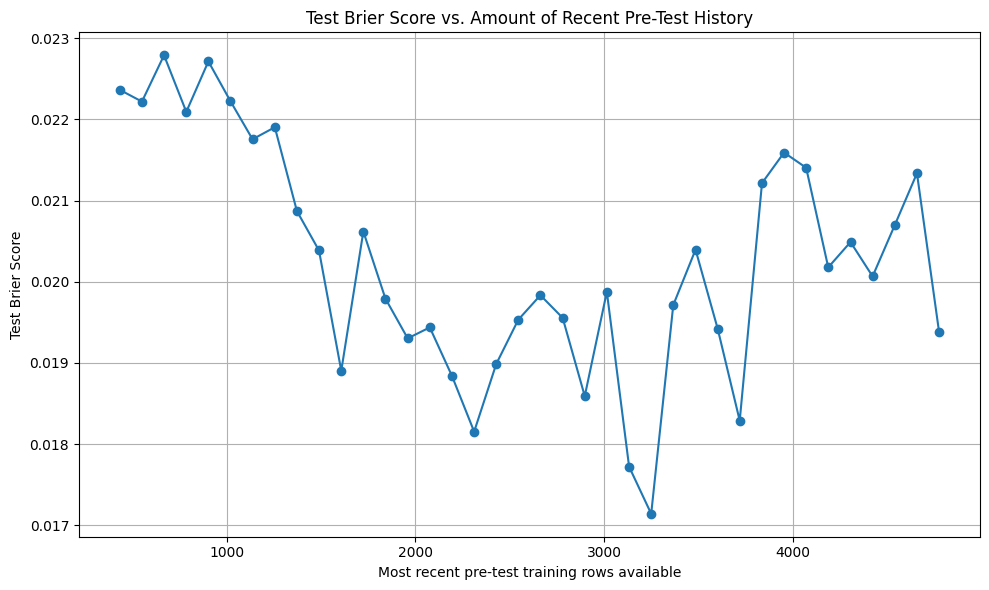

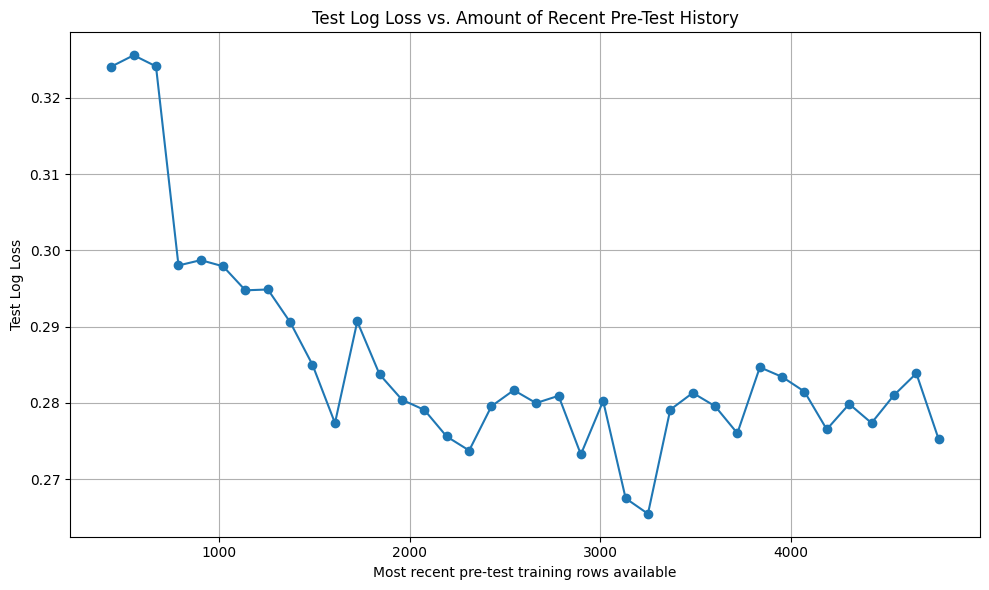


Curve summary
 requested_recent_train_rows  fit_rows_after_trim                 fit_window_start                   fit_window_end  test_brier  test_logloss
                         435                  256 2026-02-14 19:17:42.092263+00:00 2026-02-15 03:34:41.673915+00:00    0.022363      0.324126
                         552                  373 2026-02-14 15:10:02.295365+00:00 2026-02-15 03:34:41.673915+00:00    0.022218      0.325604
                         669                  490 2026-02-14 11:02:20.191443+00:00 2026-02-15 03:34:41.673915+00:00    0.022789      0.324150
                         787                  608 2026-02-14 06:55:51.229230+00:00 2026-02-15 03:34:41.673915+00:00    0.022092      0.298036
                         904                  725 2026-02-14 03:49:33.632057+00:00 2026-02-15 03:34:41.673915+00:00    0.022713      0.298732
                        1021                  842 2026-02-13 23:42:22.880661+00:00 2026-02-15 03:34:41.673915+00:00    0.022223      

,requested_recent_train_rows,fit_rows_after_trim,fit_window_start,fit_window_end,test_brier,test_logloss
0,435,256,2026-02-14 19:17:42.092263+00:00,2026-02-15 03:34:41.673915+00:00,0.022363,0.324126
1,552,373,2026-02-14 15:10:02.295365+00:00,2026-02-15 03:34:41.673915+00:00,0.022218,0.325604
2,669,490,2026-02-14 11:02:20.191443+00:00,2026-02-15 03:34:41.673915+00:00,0.022789,0.324150
3,787,608,2026-02-14 06:55:51.229230+00:00,2026-02-15 03:34:41.673915+00:00,0.022092,0.298036
4,904,725,2026-02-14 03:49:33.632057+00:00,2026-02-15 03:34:41.673915+00:00,0.022713,0.298732
5,1021,842,2026-02-13 23:42:22.880661+00:00,2026-02-15 03:34:41.673915+00:00,0.022223,0.297925
6,1138,959,2026-02-13 19:33:44.989715+00:00,2026-02-15 03:34:41.673915+00:00,0.021754,0.294774
7,1256,1077,2026-02-13 15:25:45.181083+00:00,2026-02-15 03:34:41.673915+00:00,0.021903,0.294882
8,1373,1194,2026-02-13 10:16:56.904845+00:00,2026-02-15 03:34:41.673915+00:00,0.020870,0.290591
9,1490,1311,2026-02-13 06:08:03.826944+00:00,2026-02-15 03:34:41.673915+00:00,0.020385,0.285014


In [31]:
# Run the pipeline
curve_df = run_recent_history_test_curve(
    block_hours=6,
    min_train_rows=MIN_TRAIN_ROWS,
    num_curve_points=NUM_CURVE_POINTS,
)

plot_recent_history_curve(curve_df)
print_curve_summary(curve_df)

curve_df